In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = 'adult_salary.csv'
df = pd.read_csv(data, sep=',\s')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.shape
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
categorical = [var for var in df.columns if df[var].dtype=='O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :\n\n', categorical)

There are 0 categorical variables

The categorical variables are :

 []


In [7]:
df[categorical].head()

""
0
1
2
3
4


In [8]:
df[categorical].isnull().sum()

Series([], dtype: float64)

In [9]:
df.workclass.unique()

<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                '?',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

In [10]:
df['workclass'].replace('?', np.nan, inplace=True)

0               State-gov
1        Self-emp-not-inc
2                 Private
3                 Private
4                 Private
               ...       
32556             Private
32557             Private
32558             Private
32559             Private
32560        Self-emp-inc
Name: workclass, Length: 32561, dtype: str

In [11]:
df.workclass.value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [12]:
df['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [13]:
df['occupation'].replace('?', np.nan, inplace=True)
df['native_country'].replace('?', np.nan, inplace=True)

0        United-States
1        United-States
2        United-States
3        United-States
4                 Cuba
             ...      
32556    United-States
32557    United-States
32558    United-States
32559    United-States
32560    United-States
Name: native_country, Length: 32561, dtype: str

In [14]:
df['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [15]:
df[categorical].isnull().sum()

Series([], dtype: float64)

In [16]:
for var in categorical:
    print(var,'contains', df[var].isnull().sum(), 'missing values')

In [17]:
df[categorical].head()

""
0
1
2
3
4


In [18]:
df[categorical].isnull().sum()

Series([], dtype: float64)

In [19]:
x=df.drop(['income'], axis=1)
y=df['income']

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

In [21]:
x_train.shape, x_test.shape

((22792, 14), (9769, 14))

In [22]:
categorical = [col for col in x_train.columns if x_train[col].dtypes == 'O']

categorical

[]

In [23]:
numerical = [col for col in x_train.columns if x_train[col].dtypes == 'O']

numerical

[]

In [24]:
x_train[categorical].isnull().sum()
for col in categorical:
    if x_train[col].isnull().mean()>0:
        print(col, (x_train[col].isnull().mean()))

In [25]:
for df2 in [x_train,x_test]:
    df2['workclass'].fillna(x_train['workclass'].mode()[0], inplace=True)
    df2['occupation'].fillna(x_train['occupation'].mode()[0], inplace=True)
    df2['native_country'].fillna(x_train['native_country'].mode()[0], inplace=True)    



In [26]:
x_train.isnull().sum()
x_test.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [27]:
categorical

[]

In [28]:
x_train[categorical].head()

""
32098
25206
23491
12367
7054


In [29]:
for i in categorical:
    print(x_train[i].value_counts())

In [30]:
x_train.sample(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
18470,17,?,86786,10th,6,Never-married,?,Own-child,White,Female,0,0,40,United-States
11745,33,Private,167309,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,40,United-States
3901,18,?,437851,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States
7502,40,Private,331651,Some-college,10,Separated,Other-service,Not-in-family,White,Female,0,0,40,United-States
1137,35,Federal-gov,250504,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,Black,Male,0,0,60,United-States


In [31]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical and Numerical Columns
categorical = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

numerical = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

# Category Order
category_order = {
    'workclass': [
        'Private',
        'Self-emp-not-inc',
        'Self-emp-inc',
        'Federal-gov',
        'Local-gov',
        'State-gov',
        'Without-pay',
        'Never-worked'
    ],

    'education': [
        'Bachelors',
        'Some-college',
        '11th',
        'HS-grad',
        'Prof-school',
        'Assoc-acdm',
        'Assoc-voc',
        'Masters',
        'Doctorate',
        '10th',
        '9th',
        '12th',
        '7th-8th',
        '5th-6th',
        '1st-4th',
        'Preschool'
    ],

    'marital_status': [
        'Married-civ-spouse',
        'Divorced',
        'Never-married',
        'Separated',
        'Widowed',
        'Married-spouse-absent',
        'Married-AF-spouse'
    ],

    'occupation': [
        'Tech-support',
        'Craft-repair',
        'Other-service',
        'Sales',
        'Exec-managerial',
        'Prof-specialty',
        'Handlers-cleaners',
        'Machine-op-inspct',
        'Adm-clerical',
        'Farming-fishing',
        'Transport-moving',
        'Priv-house-serv',
        'Protective-serv',
        'Armed-Forces'
    ],

    'relationship': [
        'Wife',
        'Own-child',
        'Husband',
        'Not-in-family',
        'Other-relative',
        'Unmarried'
    ],

    'race': [
        'White',
        'Asian-Pac-Islander',
        'Amer-Indian-Eskimo',
        'Other',
        'Black'
    ],

    'sex': [
        'Female',
        'Male'
    ],

    'native_country': [
        'United-States',
        'Cambodia',
        'England',
        'Puerto-Rico',
        'Canada',
        'Germany',
        'Outlying-US(Guam-USVI-etc)',
        'India',
        'Japan',
        'Greece',
        'South',
        'China',
        'Cuba',
        'Iran',
        'Honduras',
        'Philippines',
        'Italy',
        'Poland',
        'Jamaica',
        'Vietnam',
        'Mexico',
        'Portugal',
        'Ireland',
        'France',
        'Dominican-Republic',
        'Laos',
        'Ecuador',
        'Taiwan',
        'Haiti',
        'Columbia',
        'Hungary',
        'Guatemala',
        'Nicaragua',
        'Scotland',
        'Thailand',
        'Yugoslavia',
        'El-Salvador',
        'Trinadad&Tobago',
        'Peru',
        'Hong',
        'Holand-Netherlands'
    ]
}

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                categories=[category_order[col] for col in categorical],
                handle_unknown='ignore',
                sparse_output=False,
                dtype=np.int32
            ),
            categorical
        )
    ],
    remainder='passthrough'
)

# Transform Data
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

print("Train Shape:", x_train_transformed.shape)
print("Test Shape:", x_test_transformed.shape)

Train Shape: (22792, 105)
Test Shape: (9769, 105)


In [32]:
x_train.transform

<bound method DataFrame.transform of        age  workclass  fnlwgt     education  education_num  \
32098   45    Private  170871       HS-grad              9   
25206   47  State-gov  108890       HS-grad              9   
23491   48    Private  187505  Some-college             10   
12367   29    Private  145592       HS-grad              9   
7054    23    Private  203003       7th-8th              4   
...    ...        ...     ...           ...            ...   
13123   43  Local-gov   33331       Masters             14   
19648   44    Private   98466          10th              6   
9845    23    Private   45317  Some-college             10   
10799   45  Local-gov  215862     Doctorate             16   
2732    25    Private  186925  Some-college             10   

           marital_status       occupation   relationship   race     sex  \
32098  Married-civ-spouse     Craft-repair        Husband  White    Male   
25206            Divorced     Adm-clerical      Unmarried  White  

In [33]:
x_test.transform

<bound method DataFrame.transform of        age         workclass  fnlwgt     education  education_num  \
22278   27           Private  177119  Some-college             10   
8950    27           Private  216481     Bachelors             13   
7838    25           Private  256263    Assoc-acdm             12   
16505   46           Private  147640       5th-6th              3   
19140   45           Private  172822          11th              7   
...    ...               ...     ...           ...            ...   
21949   46           Private  192963     Bachelors             13   
26405   64       Federal-gov  388594   Prof-school             15   
23236   54      Self-emp-inc  304570     Bachelors             13   
26823   36  Self-emp-not-inc   90159  Some-college             10   
20721   22           Private   83315       HS-grad              9   

           marital_status         occupation   relationship  \
22278            Divorced       Adm-clerical      Unmarried   
8950    

In [34]:
preprocessor.get_feature_names_out()

array(['cat__workclass_Private', 'cat__workclass_Self-emp-not-inc',
       'cat__workclass_Self-emp-inc', 'cat__workclass_Federal-gov',
       'cat__workclass_Local-gov', 'cat__workclass_State-gov',
       'cat__workclass_Without-pay', 'cat__workclass_Never-worked',
       'cat__education_Bachelors', 'cat__education_Some-college',
       'cat__education_11th', 'cat__education_HS-grad',
       'cat__education_Prof-school', 'cat__education_Assoc-acdm',
       'cat__education_Assoc-voc', 'cat__education_Masters',
       'cat__education_Doctorate', 'cat__education_10th',
       'cat__education_9th', 'cat__education_12th',
       'cat__education_7th-8th', 'cat__education_5th-6th',
       'cat__education_1st-4th', 'cat__education_Preschool',
       'cat__marital_status_Married-civ-spouse',
       'cat__marital_status_Divorced',
       'cat__marital_status_Never-married',
       'cat__marital_status_Separated', 'cat__marital_status_Widowed',
       'cat__marital_status_Married-spouse-absent',

In [35]:
feature_names = preprocessor.get_feature_names_out()
x_train_encoded = pd.DataFrame(x_train_transformed, columns=feature_names)
x_test_encoded = pd.DataFrame(x_test_transformed, columns=feature_names)
print(x_train_encoded.tail(5))

       cat__workclass_Private  cat__workclass_Self-emp-not-inc  \
22787                       0                                0   
22788                       1                                0   
22789                       1                                0   
22790                       0                                0   
22791                       1                                0   

       cat__workclass_Self-emp-inc  cat__workclass_Federal-gov  \
22787                            0                           0   
22788                            0                           0   
22789                            0                           0   
22790                            0                           0   
22791                            0                           0   

       cat__workclass_Local-gov  cat__workclass_State-gov  \
22787                         1                         0   
22788                         0                         0   
22789                  

In [36]:
print(type(x_train_encoded))
print(type(x_test_encoded))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [37]:
x_train.shape
x_test.shape

(9769, 14)

In [38]:
x_train_encoded.shape
x_test_encoded.shape

(9769, 105)

In [39]:
cols = x_train_encoded.columns
cols

Index(['cat__workclass_Private', 'cat__workclass_Self-emp-not-inc',
       'cat__workclass_Self-emp-inc', 'cat__workclass_Federal-gov',
       'cat__workclass_Local-gov', 'cat__workclass_State-gov',
       'cat__workclass_Without-pay', 'cat__workclass_Never-worked',
       'cat__education_Bachelors', 'cat__education_Some-college',
       ...
       'cat__native_country_Trinadad&Tobago', 'cat__native_country_Peru',
       'cat__native_country_Hong', 'cat__native_country_Holand-Netherlands',
       'remainder__age', 'remainder__fnlwgt', 'remainder__education_num',
       'remainder__capital_gain', 'remainder__capital_loss',
       'remainder__hours_per_week'],
      dtype='str', length=105)

In [40]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_s = scaler.fit_transform(x_train_encoded)
X_test_s = scaler.transform(x_test_encoded)

In [41]:
X_train_s = pd.DataFrame(X_train_s, columns=[cols])
X_test_s = pd.DataFrame(X_test_s, columns=[cols])
X_train_s.head()


,cat__workclass_Private,cat__workclass_Self-emp-not-inc,cat__workclass_Self-emp-inc,cat__workclass_Federal-gov,cat__workclass_Local-gov,cat__workclass_State-gov,cat__workclass_Without-pay,cat__workclass_Never-worked,cat__education_Bachelors,cat__education_Some-college,...,cat__native_country_Trinadad&Tobago,cat__native_country_Peru,cat__native_country_Hong,cat__native_country_Holand-Netherlands,remainder__age,remainder__fnlwgt,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.40,-0.058906,-0.333333,7298.0,0.0,4.0
1,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.50,-0.578076,-0.333333,1831.0,0.0,-0.4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.55,0.080425,0.000000,0.0,0.0,2.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.40,-0.270650,-0.333333,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.70,0.210240,-2.000000,0.0,0.0,-3.0


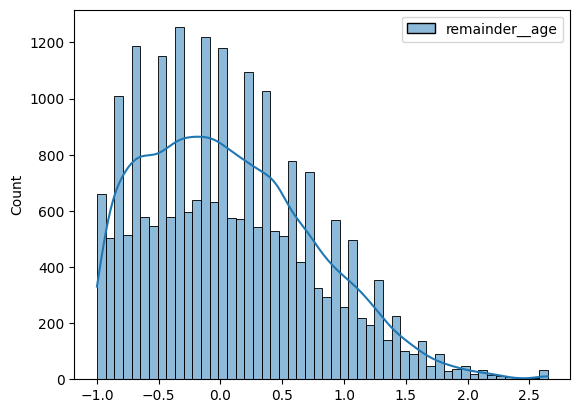

In [42]:
sns.histplot(X_train_s['remainder__age'],kde=True)
plt.show()

In [43]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_s, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [44]:
y_pred = gnb.predict(X_test_s)
y_pred

array(['<=50K', '<=50K', '>50K', ..., '>50K', '<=50K', '<=50K'],
      shape=(9769,), dtype='<U5')

In [45]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.8059


In [46]:
y_pred_train = gnb.predict(X_train_s)

y_pred_train

array(['>50K', '<=50K', '>50K', ..., '<=50K', '>50K', '<=50K'],
      shape=(22792,), dtype='<U5')

In [49]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.8030


In [48]:
print('Training set score: {:.4f}'.format(gnb.score(X_train_s, y_train)))

print('Test set score: {:.4f}'.format(gnb.score(X_test_s, y_test)))

Training set score: 0.8030
Test set score: 0.8059


In [47]:

y_test.value_counts()

income
<=50K    7407
>50K     2362
Name: count, dtype: int64

In [50]:
null_accuracy = (7407/(7407+2362))

print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

Null accuracy score: 0.7582
